# 03 · Support Vector Machines

**Objectives:** train an SVM classifier on real flower measurements, see how the
kernel and margin shape its decision boundary, and read a confusion matrix.

A support vector machine looks for the boundary between classes that leaves the
**widest possible margin** to the nearest points of each class (the "support
vectors"). With a kernel it can bend that boundary into a curve.

## 1. A straight boundary and the distance to it

Start with two classes. Training example $i$ has a feature vector $x_i$ of $p$ numbers (below, $p = 2$: petal length and width, in cm) and a label $y_i$ equal to $+1$ or $-1$. A **linear classifier** has a weight vector $w$ (also $p$ numbers) and a number $b$, the bias. It predicts

$$\hat y = \mathrm{sign}\big(w^\top x + b\big)$$

where $w^\top x = w_1 x_1 + \dots + w_p x_p$ is the dot product. The **decision function** $f(x) = w^\top x + b$ is positive on one side of the boundary and negative on the other. The boundary itself, where $f(x) = 0$, is a **hyperplane**: a line when $p = 2$, a plane when $p = 3$.

**$w$ is perpendicular to the boundary.** Two points $x_a$ and $x_b$ on the boundary satisfy $w^\top x_a + b = 0$ and $w^\top x_b + b = 0$. Subtracting gives $w^\top (x_a - x_b) = 0$: $w$ is at a right angle to every direction that lies along the boundary.

**Distance to the boundary.** Take any point $x$ and let $x_0$ be the closest point on the boundary. The shortest path from the boundary to $x$ runs along the perpendicular, the unit vector $w / \lVert w \rVert$, where $\lVert w \rVert = \sqrt{w^\top w}$ is the length of $w$. So $x = x_0 + t\, w / \lVert w \rVert$ for some number $t$, the signed distance. Apply $f$ to both sides:

$$f(x) = \underbrace{w^\top x_0 + b}_{=\,0} + \; t\,\frac{w^\top w}{\lVert w \rVert} = t\,\lVert w \rVert$$

Solving for $t$ and dropping the sign:

$$\text{distance}(x) = \frac{\lvert w^\top x + b \rvert}{\lVert w \rVert}$$

In words: the decision function, divided by the length of $w$, measures how far a point is from the boundary; its sign says on which side.

## 2. The widest margin

If a straight line can separate the two classes, many lines can. The SVM picks the one farthest from the closest points of both classes. The **margin** is the distance from the boundary to the nearest training point.

**Fixing the scale.** Multiplying $w$ and $b$ by the same positive number leaves the boundary $f = 0$ where it is. So we may scale them until the closest points satisfy $\lvert w^\top x_i + b \rvert = 1$. By Section 1 these points sit at distance $1/\lVert w \rVert$, and the empty band between the lines $w^\top x + b = \pm 1$ is $2/\lVert w \rVert$ wide. "Every point is on its correct side and at least that far away" becomes one inequality per point (multiplying by the label makes both classes read "positive"):

$$y_i\big(w^\top x_i + b\big) \ge 1 \quad \text{for all } i$$

Making the margin $1/\lVert w \rVert$ as large as possible is the same as making $\lVert w \rVert$ as small as possible. This gives the **hard-margin SVM**:

$$\min_{w,\,b}\ \tfrac12 \lVert w \rVert^2 \quad \text{subject to} \quad y_i\big(w^\top x_i + b\big) \ge 1 \ \text{ for all } i$$

Squaring and the $\tfrac12$ do not move the minimiser; they make the objective a smooth convex bowl with a single global minimum (chapter 02).

**A hand example.** Take the line $x_1 + x_2 = 4$, that is $w = (1, 1)$ and $b = -4$, so $\lVert w \rVert = \sqrt 2 \approx 1.414$.

| point | $x$ | $y$ | $f(x) = x_1 + x_2 - 4$ | $y\,f(x)$ | distance $\lvert f(x) \rvert / \sqrt 2$ | status |
|---|---|---|---|---|---|---|
| A | (1, 1) | −1 | −2 | 2 | 1.414 | beyond the margin |
| B | (2, 1) | −1 | −1 | 1 | 0.707 | on the margin |
| C | (3, 2) | +1 | 1 | 1 | 0.707 | on the margin |
| D | (4, 3) | +1 | 3 | 3 | 2.121 | beyond the margin |

Every point satisfies $y\,f(x) \ge 1$. B and C have $y\,f(x) = 1$ exactly: they sit on the margin, and the band between the classes is $2/\sqrt 2 \approx 1.414$ wide. No line can do better, since B and C are only $\sqrt 2$ apart, so this is the SVM solution. Moving A or D a little changes nothing; B and C pin the boundary in place. They are the **support vectors**.

**Soft margin.** Real classes overlap, so some points must be allowed inside the margin or on the wrong side. Each point gets a **slack** $\xi_i \ge 0$ measuring its violation, charged at a price $C > 0$ per unit:

$$\min_{w,\,b,\,\xi}\ \tfrac12 \lVert w \rVert^2 + C \sum_i \xi_i \quad \text{subject to} \quad y_i\big(w^\top x_i + b\big) \ge 1 - \xi_i, \ \ \xi_i \ge 0$$

A point with $\xi_i = 0$ respects the margin; $0 < \xi_i \le 1$ means inside the margin but on the correct side; $\xi_i > 1$ means misclassified. At the optimum each slack is as small as allowed, $\xi_i = \max\big(0,\ 1 - y_i f(x_i)\big)$, which gives an equivalent problem without constraints:

$$\min_{w,\,b}\ \tfrac12 \lVert w \rVert^2 + C \sum_i \max\big(0,\ 1 - y_i(w^\top x_i + b)\big)$$

The second term is the **hinge loss**: zero for points beyond the margin on the correct side, growing linearly as a point enters the margin or crosses the boundary. (A point F $= (2.5, 2)$ with label $-1$ would have $y\,f = -0.5$ above, so a hinge loss of $1.5$.) The first term asks for a wide margin, the second for few violations, and $C$ sets the exchange rate: a large $C$ gives a narrow margin that follows the training points closely, a small $C$ a wide margin that tolerates more violations.

## 3. Kernels: curved boundaries from dot products

Two facts about the solution make curved boundaries possible.

**$w$ is built from the training points.** Split $w$ into a combination of the training points plus a part $w_\perp$ perpendicular to all of them. $w_\perp$ changes no value $w^\top x_i$, so it helps no constraint, but it adds $\lVert w_\perp \rVert^2$ to the objective; at the optimum it is zero. Writing the weights of the combination as $\alpha_i y_i$:

$$w = \sum_i \alpha_i y_i\, x_i, \qquad f(x) = \sum_i \alpha_i y_i\, x_i^\top x + b$$

The optimality conditions (Lagrange multipliers) add that $0 \le \alpha_i \le C$, and that $\alpha_i = 0$ for every point strictly beyond the margin, $y_i f(x_i) > 1$: such a point pays no hinge loss, even if it moves a little, so it has no say. The points with $\alpha_i > 0$ (on the margin, inside it, or misclassified) are the support vectors, and $f$ is a sum over them only. In the example, $\alpha_{\text{B}} = \alpha_{\text{C}} = 1$ and $\alpha_{\text{A}} = \alpha_{\text{D}} = 0$ give $w = -\text{B} + \text{C} = (1, 1)$, as found.

**Only dot products appear.** Substituting $w$ back turns training into a problem over the $\alpha_i$ alone (the *dual* problem, which is what solvers work with):

$$\max_{\alpha}\ \sum_i \alpha_i - \tfrac12 \sum_{i,j} \alpha_i \alpha_j\, y_i y_j\, x_i^\top x_j \quad \text{subject to} \quad 0 \le \alpha_i \le C, \ \ \sum_i \alpha_i y_i = 0$$

The data enter only through dot products $x_i^\top x_j$, both here and in $f(x)$.

**The kernel trick.** Replace every dot product by a **kernel** $k(x, z)$ equal to $\varphi(x)^\top \varphi(z)$ for some map $\varphi$ into a larger feature space. The SVM then draws a straight boundary in that space, curved in the original one, without ever computing $\varphi$. For example, with $p = 2$ the kernel $k(x, z) = (x^\top z)^2 = x_1^2 z_1^2 + 2 x_1 x_2 z_1 z_2 + x_2^2 z_2^2$ equals $\varphi(x)^\top \varphi(z)$ with $\varphi(x) = (x_1^2,\ \sqrt 2\, x_1 x_2,\ x_2^2)$; a flat boundary in those three coordinates is an ellipse or a hyperbola in the plane. The decision function becomes

$$f(x) = \sum_{i \,\in\, \text{support vectors}} \alpha_i y_i\, k(x_i, x) + b$$

**The RBF kernel** (radial basis function, or Gaussian) is

$$k(x, x') = \exp\!\big(-\gamma\, \lVert x - x' \rVert^2\big)$$

It equals 1 when $x = x'$ and decays towards 0 as the points move apart. Each support vector adds a bump centred on itself, and the boundary is where the sum of bumps crosses zero. $\gamma > 0$ (units of $1/\text{cm}^2$ here) sets the bump width, about $1/\sqrt\gamma$. With $\gamma = 1$, points at distance $0.5$, $1$ and $2$ get similarities $e^{-0.25} \approx 0.78$, $e^{-1} \approx 0.37$ and $e^{-4} \approx 0.02$. A large $\gamma$ gives narrow bumps and a boundary that can wrap around single points (overfitting); a small $\gamma$ gives an almost straight boundary.

**More than two classes.** scikit-learn's `SVC` trains one SVM per pair of classes (*one-vs-one*: 3 SVMs for three species) and predicts the class winning the most pairwise votes.

**In the code below.** `X` holds petal length and width (cm) for each flower, `y` the species. `SVC(kernel="rbf", C=1.0, gamma="scale")` solves the soft-margin problem with the RBF kernel and $C = 1$; `gamma="scale"` sets $\gamma = 1/(p \cdot \mathrm{Var})$, with $p = 2$ and $\mathrm{Var}$ the variance of all entries of `X_train`. `svm.n_support_` counts the support vectors of each class (the points with $\alpha_i > 0$), and `svm.support_vectors_` holds their coordinates, circled in the boundary plot.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import mlutils
mlutils.set_style()

## 4. The data

Fisher's iris dataset: 150 flowers, 3 species, 4 measurements each. To draw a 2D
decision boundary we'll use just petal length and petal width — the two measurements
that separate the species best.

In [2]:
iris = pd.read_csv("data/iris.csv")
species = sorted(iris["species"].unique())
print(iris.shape, species)
iris.head()

(150, 5) ['setosa', 'versicolor', 'virginica']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


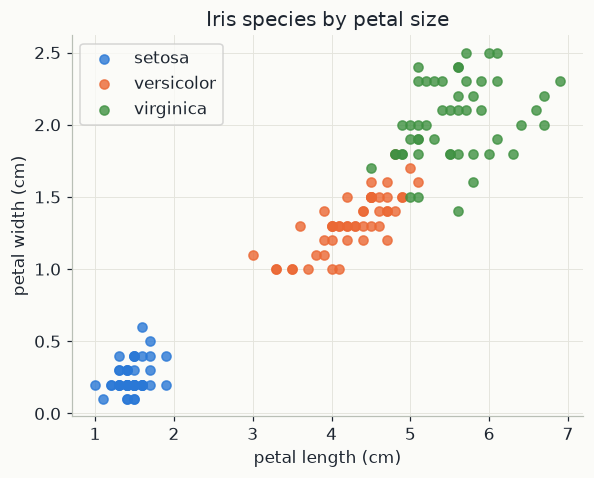

In [3]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for sp_name, color in zip(species, mlutils.PALETTE):
    sub = iris[iris["species"] == sp_name]
    ax.scatter(sub["petal_length"], sub["petal_width"], label=sp_name, color=color, alpha=0.8)
ax.set(xlabel="petal length (cm)", ylabel="petal width (cm)", title="Iris species by petal size")
ax.legend()

`setosa` is already linearly separable from the other two just by petal size;
`versicolor` and `virginica` overlap more. That's the interesting part for a
classifier to resolve.

## 5. Fitting the SVM

We hold out 30% of the flowers as a test set, fit an RBF-kernel SVM (a Gaussian
kernel — it can draw curved boundaries) on the rest, and score it on flowers it never
saw during training.

In [4]:
X = iris[["petal_length", "petal_width"]].values
y = iris["species"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

svm = SVC(kernel="rbf", C=1.0, gamma="scale").fit(X_train, y_train)
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"test accuracy: {acc:.3f}  ({len(X_test)} held-out flowers)")
print(f"support vectors used: {svm.n_support_.sum()} of {len(X_train)} training points")

test accuracy: 0.933  (45 held-out flowers)
support vectors used: 34 of 105 training points


## 6. The decision boundary

Because we only used 2 features, the boundary the SVM learned can be drawn directly:
colour every point of the plane by what the model would predict there.

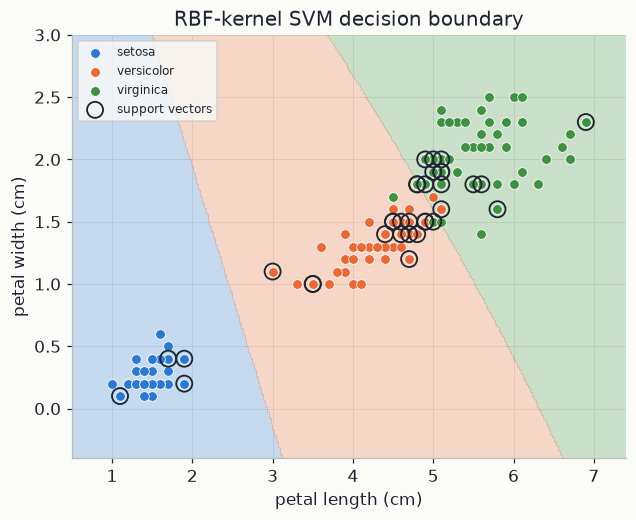

In [5]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
label_to_int = {s: i for i, s in enumerate(species)}
Z = np.array([label_to_int[p] for p in svm.predict(np.c_[xx.ravel(), yy.ravel()])]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.contourf(xx, yy, Z, alpha=0.25, colors=mlutils.PALETTE[:3], levels=[-0.5, 0.5, 1.5, 2.5])
for sp_name, color in zip(species, mlutils.PALETTE):
    sub = iris[iris["species"] == sp_name]
    ax.scatter(sub["petal_length"], sub["petal_width"], label=sp_name, color=color,
               edgecolor="white", linewidth=0.5, s=40)
ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1], s=110, facecolors="none",
           edgecolors=mlutils.INK, linewidth=1.2, label="support vectors")
ax.set(xlabel="petal length (cm)", ylabel="petal width (cm)", title="RBF-kernel SVM decision boundary")
ax.legend(loc="upper left", fontsize=8)

Only the **support vectors** (circled) determine where the boundary sits — every
other training point could move around freely without changing the fit at all, as
long as it doesn't cross into the margin. That's what makes SVMs memory-efficient at
prediction time: the boundary is a function of a handful of points, not the whole
dataset.

Text(0.5, 1.0, 'Confusion matrix, held-out flowers')

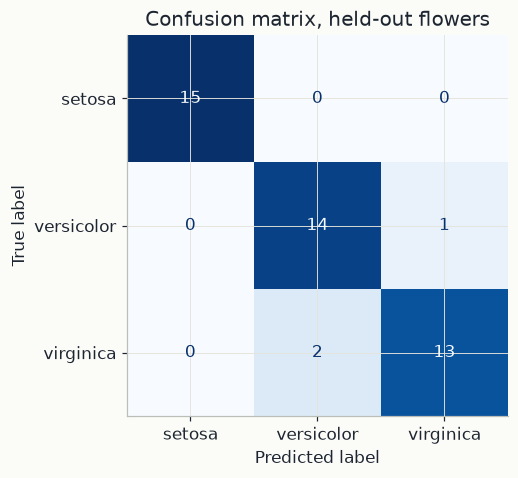

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=species)
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=species).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix, held-out flowers")

## Exercises

### Exercise 1: Linear vs. RBF kernel
Refit with `kernel="linear"`. Does accuracy change much? Plot its decision boundary
next to the RBF one — where does a straight boundary struggle that a curved one
doesn't?

<details><summary>Solution</summary>

```python
svm_linear = SVC(kernel="linear", C=1.0).fit(X_train, y_train)
print(accuracy_score(y_test, svm_linear.predict(X_test)))
```
On this dataset the classes are nearly linearly separable already, so the linear
kernel does almost as well — the RBF boundary's curvature only matters in the small
overlap region between versicolor and virginica.
</details>

### Exercise 2: The cost of a small margin
Try `C=1000` (very little tolerance for margin violations) and `C=0.01` (very
tolerant). Compare the number of support vectors and the test accuracy in each case.

<details><summary>Solution</summary>

A large `C` chases every training point, uses more support vectors, and can overfit
the overlap region; a very small `C` allows a wide, smoother margin and often
generalises about as well with far fewer support vectors — a direct look at the
bias-variance trade-off.
</details>

## Key takeaways

- An SVM finds the boundary with the widest margin to the nearest points of each
  class; those nearest points (the support vectors) are the only ones the boundary
  actually depends on.
- A kernel (here, RBF) lets the boundary curve through feature space without
  explicitly constructing new features.
- `C` trades off margin width against tolerance for misclassified training points —
  it's the SVM's main regularisation knob.